In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# 1. Load and Preprocess the dataset
# FIX: Added sep='\t' and names=['label', 'text'] because the file is tab-separated and has no header
df = pd.read_csv("data/spamhamdata.csv", sep='\t', names=['label', 'text'])

# Check for null values
print("--- Null Value Check ---")
print(df.isnull().sum())

# Check for duplicates
# 1.1. Check duplicates initially
initial_dupes = df.duplicated(subset=['text']).sum()
print(f"Duplicates before cleaning: {initial_dupes}")

# 1.2. Remove duplicates
df = df.drop_duplicates(subset=['text'], keep='first')

# 1.3. VERIFY: Check duplicates again (Should be 0)
final_dupes = df.duplicated(subset=['text']).sum()
print(f"Duplicates after cleaning: {final_dupes}")
print(f"Total unique emails remaining: {len(df)}")

# 1.4. Map string labels 'ham'/'spam' to numbers 0 and 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X_texts = df['text']
y = df['label_num']

--- Null Value Check ---
label    0
text     0
dtype: int64
Duplicates before cleaning: 403
Duplicates after cleaning: 0
Total unique emails remaining: 5169


In [3]:
# 2. Split with Stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_texts, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [4]:
# 3. Vectorize (Bag of Words)
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

In [5]:
# 4. Train the Naive Bayes Classifier
model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

In [6]:
# 5. Evaluate the results
y_pred = model.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


Model Accuracy: 98.16%

Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.94      0.92      0.93       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [7]:
# 6. Test with your specific 'fake' Retail Phishing emails
fake_emails = [
    "URGENT: Your retail invoice for $500 is overdue. Pay now.",
    "Congratulations! You've won a $1000 Walmart gift card! Click here.",
    "Verify your Amazon account password immediately to avoid suspension.",
    "Please find the attached report regarding the energy meeting tomorrow.",
    "Hey, are we still playing badminton this weekend at the college court?",
    "Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account! Your code is: 27909 Sincerely,CompTIA",
    "By completing the required activities, you have acquired:Badge 3 Day Streak Ownership of this badge is automatic and non-transferable. Side effects may include confidence and the desire to earn another one.No response expected or monitored. Keep on keeping on! ",
    "Hello and welcome,Your application for our Adobe certification and project internship has been moved to the shortlist for the next phase. We look forward to the possibility of you joining our upcoming cohort.Through this internship, you will have the chance to earn industry certifications and create a portfolio that reflects your hands-on experience. These verified skills are essential for showing employers exactly what you can achieve with digital tools.Please complete your registration by visiting the personalized portal link below. This will confirm your interest and allow us to process your final application details.Complete your application via this link: https://forms.gle/MS9zb7LgJcNSincerely yours,Program Director, Digital Skills Internship "
]

X_fake = vectorizer.transform(fake_emails)
predictions = model.predict(X_fake) 
probs = model.predict_proba(X_fake) # for probability instead of a direct 'spam' 'ham'

print("\n--- Manual Retail Test Results with Confidence ---")
for i, email in enumerate(fake_emails):
    pred = predictions[i]
    confidence = probs[i][pred] * 100 #converts probability into percentage
    label = "🚨 SPAM" if pred == 1 else "✅ HAM"
    print(f"[{label}] ({confidence:.2f}% confidence) -> {email}")


--- Manual Retail Test Results with Confidence ---
[🚨 SPAM] (98.14% confidence) -> URGENT: Your retail invoice for $500 is overdue. Pay now.
[🚨 SPAM] (100.00% confidence) -> Congratulations! You've won a $1000 Walmart gift card! Click here.
[🚨 SPAM] (77.82% confidence) -> Verify your Amazon account password immediately to avoid suspension.
[✅ HAM] (99.93% confidence) -> Please find the attached report regarding the energy meeting tomorrow.
[✅ HAM] (99.94% confidence) -> Hey, are we still playing badminton this weekend at the college court?
[🚨 SPAM] (98.84% confidence) -> Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account! Your code is: 27909 Sincerely,CompTIA
[✅ HAM] (99.83% confidence) -> By completing the required activities, you have acquired:Badge 3 Day Streak Ownership of this badge is automatic and non-transferable. Side effects may include confidence and the desire to earn another one.No response expected or monitored. 

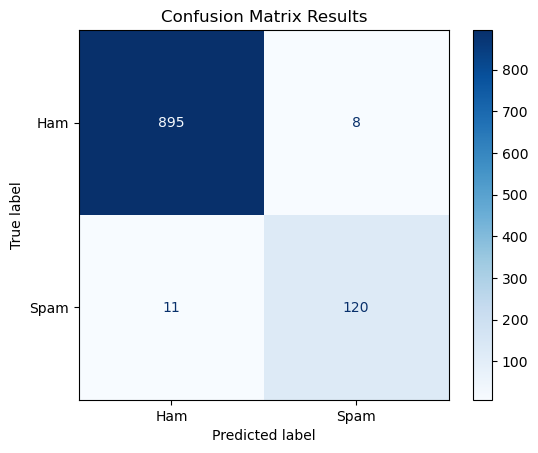

In [8]:
# 7. Plotting
# This line calculates the matrix AND draws the plot
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Ham', 'Spam'], cmap='Blues')

plt.title("Confusion Matrix Results") #Adds title
plt.savefig("confusion_matrix.png") # Saves the image 
plt.show()  # add this line

In [9]:
# 8. GUI
import gradio as gr

def predict_email(email_text):
    X = vectorizer.transform([email_text])
    pred = model.predict(X)[0]
    prob = model.predict_proba(X)[0]
    confidence = prob[pred] * 100
    label = "🚨 SPAM" if pred == 1 else "✅ HAM"
    return f"{label} — {confidence:.2f}% confidence"

demo = gr.Interface(
    fn=predict_email,
    inputs=gr.Textbox(lines=5, placeholder="Paste email here..."),
    outputs="text",
    title="Retail Phishing Detector",
    description="Enter an email to check if it's spam or legitimate."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [10]:
# 9. View Flagged Emails
import pandas as pd
import os

flagged_path = "/Users/aishahsyed/.gradio/flagged/dataset1.csv"

if os.path.exists(flagged_path):
    flagged = pd.read_csv(flagged_path)
    print("--- Flagged Emails Log ---")
    print(f"Total flagged emails: {len(flagged)}")
    print()
    print(flagged.to_string())
else:
    print("No flagged emails yet. Click the Flag button in the GUI to log an incorrect prediction.")

--- Flagged Emails Log ---
Total flagged emails: 4

                                                                                                                                             email_text                       output                   timestamp
0                            "Your account has been suspended, verify now"\n"You've won a prize, click here"\n"Urgent invoice overdue, pay immediately"  🚨 SPAM — 100.00% confidence  2026-04-20 11:08:04.949392
1  Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account! Your code is: 27909 Sincerely,CompTIA   🚨 SPAM — 98.84% confidence  2026-04-25 12:07:10.780076
2  Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account! Your code is: 27909 Sincerely,CompTIA   🚨 SPAM — 98.84% confidence  2026-04-25 12:07:19.590175
3  Verify Your Email Address Thanks for verifying your lmno2005@gmail.com email address for your CompTIA account

In [1]:
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "streamlit"], check=True)

  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 2.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.5/206.5 kB 4.0 MB/s eta 0:00:00a 0:00:01
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.0/175.0 kB 1.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: itsdangerous
    Found existing installation: itsdangerous 2.0.1
    Uninstalling itsdangerous-2.0.1:
      Successfully uninstalled itsdangerous-2.0.1
  Attempting uninstall: cachetools
    Found existing installation: cachetools 4.2.2
    Uninstalling cachetools-4.2.2:
      Successfully uninstalled cachetools-4.2.2
  Attempting uninstall: streamlit
    Found existing installation: streamlit 1.30.0
    Uninstalling streamlit-1.30.0:
      Successfully uninstalled streamlit-1.30.0


CompletedProcess(args=['/opt/anaconda3/bin/python', '-m', 'pip', 'install', '--upgrade', 'streamlit'], returncode=0)

In [4]:
%%writefile /Users/aishahsyed/dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import os

# ─────────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────────
st.set_page_config(
    page_title="Retail Phishing Detector",
    page_icon="🛡️",
    layout="wide"
)

# ─────────────────────────────────────────────
# CUSTOM CSS
# ─────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=Inter:wght@300;400;600;700&display=swap');

html, body, [class*="css"] {
    font-family: 'Inter', sans-serif;
    background-color: #0a0e1a;
    color: #e0e6f0;
}

.main {
    background-color: #0a0e1a;
}

h1, h2, h3 {
    font-family: 'Space Mono', monospace;
    color: #00d4ff;
}

.metric-card {
    background: linear-gradient(135deg, #0f1629 0%, #1a2444 100%);
    border: 1px solid #00d4ff33;
    border-radius: 12px;
    padding: 20px;
    text-align: center;
    box-shadow: 0 4px 20px rgba(0, 212, 255, 0.1);
}

.metric-value {
    font-family: 'Space Mono', monospace;
    font-size: 2.5rem;
    font-weight: 700;
    color: #00d4ff;
}

.metric-label {
    font-size: 0.85rem;
    color: #8892a4;
    text-transform: uppercase;
    letter-spacing: 1px;
    margin-top: 5px;
}

.spam-badge {
    background: linear-gradient(135deg, #ff4444, #cc0000);
    color: white;
    padding: 8px 20px;
    border-radius: 20px;
    font-family: 'Space Mono', monospace;
    font-weight: 700;
    font-size: 1.2rem;
    display: inline-block;
}

.ham-badge {
    background: linear-gradient(135deg, #00cc66, #007744);
    color: white;
    padding: 8px 20px;
    border-radius: 20px;
    font-family: 'Space Mono', monospace;
    font-weight: 700;
    font-size: 1.2rem;
    display: inline-block;
}

.section-header {
    border-left: 4px solid #00d4ff;
    padding-left: 15px;
    margin: 30px 0 20px 0;
}

.stTextArea textarea {
    background-color: #0f1629 !important;
    color: #e0e6f0 !important;
    border: 1px solid #00d4ff44 !important;
    border-radius: 8px !important;
    font-family: 'Inter', sans-serif !important;
}

.stButton button {
    background: linear-gradient(135deg, #00d4ff, #0099cc) !important;
    color: #0a0e1a !important;
    font-family: 'Space Mono', monospace !important;
    font-weight: 700 !important;
    border: none !important;
    border-radius: 8px !important;
    padding: 10px 30px !important;
    width: 100% !important;
}

.stButton button:hover {
    background: linear-gradient(135deg, #00ffcc, #00d4ff) !important;
    transform: translateY(-2px) !important;
}

.sidebar .sidebar-content {
    background-color: #0f1629 !important;
}

div[data-testid="stSidebar"] {
    background-color: #0f1629;
    border-right: 1px solid #00d4ff22;
}

.footer {
    text-align: center;
    color: #8892a4;
    font-size: 0.8rem;
    margin-top: 50px;
    padding: 20px;
    border-top: 1px solid #00d4ff22;
}
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────
# LOAD & TRAIN MODEL (cached)
# ─────────────────────────────────────────────
@st.cache_resource
def load_and_train():
    df = pd.read_csv("/Users/aishahsyed/data/spamhamdata.csv", sep='\t', names=['label', 'text'])
    df = df.drop_duplicates(subset=['text'], keep='first')
    df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
    X_texts = df['text']
    y = df['label_num']
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_texts, y, test_size=0.2, random_state=42, stratify=y
    )
    vectorizer = CountVectorizer(stop_words='english', max_features=1000)
    X_train = vectorizer.fit_transform(X_train_raw)
    X_test = vectorizer.transform(X_test_raw)
    model = MultinomialNB(alpha=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return model, vectorizer, df, y_test, y_pred, X_test

model, vectorizer, df, y_test, y_pred, X_test = load_and_train()

# ─────────────────────────────────────────────
# SIDEBAR
# ─────────────────────────────────────────────
with st.sidebar:
    st.markdown("## 🛡️ Retail Phishing Detector")
    st.markdown("---")
    st.markdown("**Project:** AI-Based Phishing Detection for Retail")
    st.markdown("**Student:** Aishah Syed")
    st.markdown("**University:** Yenepoya (Deemed to be University)")
    st.markdown("**Mentor:** Mr. Shashank Korram")
    st.markdown("**Guide:** Mr. Vikyath")
    st.markdown("---")
    st.markdown("**Model:** Multinomial Naive Bayes")
    st.markdown("**Features:** Bag of Words (1,000)")
    st.markdown("**Dataset:** 5,169 unique emails")
    st.markdown("**Accuracy:** 98.16%")
    st.markdown("---")
    page = st.radio("Navigate", [
        "🏠 Overview",
        "📧 Email Classifier",
        "📊 Model Performance",
        "📈 Dataset Statistics",
        "🚨 Flagged Emails"
    ])

# ─────────────────────────────────────────────
# PAGE: OVERVIEW
# ─────────────────────────────────────────────
if page == "🏠 Overview":
    st.markdown("<h1>🛡️ AI-Based Phishing Detection</h1>", unsafe_allow_html=True)
    st.markdown("<h3 style='color:#8892a4; font-family:Inter;'>for the Retail Industry</h3>", unsafe_allow_html=True)
    st.markdown("---")

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.markdown("""
        <div class='metric-card'>
            <div class='metric-value'>98.16%</div>
            <div class='metric-label'>Model Accuracy</div>
        </div>
        """, unsafe_allow_html=True)

    with col2:
        st.markdown("""
        <div class='metric-card'>
            <div class='metric-value'>5,169</div>
            <div class='metric-label'>Training Emails</div>
        </div>
        """, unsafe_allow_html=True)

    with col3:
        st.markdown("""
        <div class='metric-card'>
            <div class='metric-value'>0.94</div>
            <div class='metric-label'>Spam Precision</div>
        </div>
        """, unsafe_allow_html=True)

    with col4:
        st.markdown("""
        <div class='metric-card'>
            <div class='metric-value'>0.92</div>
            <div class='metric-label'>Spam Recall</div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("<div class='section-header'><h3>About This Project</h3></div>", unsafe_allow_html=True)
        st.markdown("""
        This dashboard presents an **AI-Based Phishing Detection System** built for the retail industry using
        Python and Scikit-Learn.

        The system uses a **Multinomial Naive Bayes** classifier trained on a public Spam vs Ham dataset
        to automatically detect phishing emails targeting retail employees.

        **Pipeline:**
        1. Load & preprocess dataset
        2. Remove 403 duplicate emails
        3. Bag of Words vectorization (1,000 features)
        4. Train Naive Bayes classifier
        5. Evaluate on 1,034 test emails
        6. Real-time classification via GUI
        """)

    with col2:
        st.markdown("<div class='section-header'><h3>Technology Stack</h3></div>", unsafe_allow_html=True)
        tech_data = {
            "Technology": ["Python", "Scikit-Learn", "Pandas", "Matplotlib", "Gradio", "Streamlit", "Jupyter Notebook"],
            "Purpose": ["Core language", "ML pipeline", "Data processing", "Visualisation", "Interactive GUI", "Dashboard", "Development"]
        }
        st.dataframe(pd.DataFrame(tech_data), use_container_width=True, hide_index=True)

# ─────────────────────────────────────────────
# PAGE: EMAIL CLASSIFIER
# ─────────────────────────────────────────────
elif page == "📧 Email Classifier":
    st.markdown("<h1>📧 Email Classifier</h1>", unsafe_allow_html=True)
    st.markdown("Paste any email below to instantly check if it is spam or legitimate.")
    st.markdown("---")

    col1, col2 = st.columns([2, 1])

    with col1:
        email_input = st.text_area(
            "Email Content",
            placeholder="Paste your email here...",
            height=200
        )

        if st.button("🔍 Classify Email"):
            if email_input.strip() == "":
                st.warning("Please paste an email to classify.")
            else:
                X = vectorizer.transform([email_input])
                pred = model.predict(X)[0]
                prob = model.predict_proba(X)[0]
                confidence = prob[pred] * 100

                st.markdown("<br>", unsafe_allow_html=True)

                if pred == 1:
                    st.markdown(f"""
                    <div style='background:linear-gradient(135deg,#1a0a0a,#2d0f0f);border:1px solid #ff444466;border-radius:12px;padding:25px;text-align:center;'>
                        <div style='font-size:3rem;'>🚨</div>
                        <div class='spam-badge'>SPAM DETECTED</div>
                        <div style='font-size:1.5rem;color:#ff6666;margin-top:15px;font-family:Space Mono,monospace;'>{confidence:.2f}% confidence</div>
                        <div style='color:#8892a4;margin-top:10px;'>This email shows characteristics of a phishing attempt.</div>
                    </div>
                    """, unsafe_allow_html=True)
                else:
                    st.markdown(f"""
                    <div style='background:linear-gradient(135deg,#0a1a0f,#0f2d1a);border:1px solid #00cc6644;border-radius:12px;padding:25px;text-align:center;'>
                        <div style='font-size:3rem;'>✅</div>
                        <div class='ham-badge'>LEGITIMATE EMAIL</div>
                        <div style='font-size:1.5rem;color:#00cc66;margin-top:15px;font-family:Space Mono,monospace;'>{confidence:.2f}% confidence</div>
                        <div style='color:#8892a4;margin-top:10px;'>This email appears to be legitimate.</div>
                    </div>
                    """, unsafe_allow_html=True)

    with col2:
        st.markdown("<div class='section-header'><h3>Quick Test Emails</h3></div>", unsafe_allow_html=True)
        st.markdown("**🚨 Spam Examples:**")
        if st.button("Invoice Scam"):
            st.session_state['quick_email'] = "URGENT: Your retail invoice for $500 is overdue. Pay now."
        if st.button("Gift Card Scam"):
            st.session_state['quick_email'] = "Congratulations! You've won a $1000 Walmart gift card! Click here."
        if st.button("Account Verify Scam"):
            st.session_state['quick_email'] = "Verify your Amazon account password immediately to avoid suspension."

        st.markdown("**✅ Ham Examples:**")
        if st.button("Business Email"):
            st.session_state['quick_email'] = "Please find the attached report regarding the energy meeting tomorrow."
        if st.button("Casual Email"):
            st.session_state['quick_email'] = "Hey, are we still playing badminton this weekend at the college court?"

# ─────────────────────────────────────────────
# PAGE: MODEL PERFORMANCE
# ─────────────────────────────────────────────
elif page == "📊 Model Performance":
    st.markdown("<h1>📊 Model Performance</h1>", unsafe_allow_html=True)
    st.markdown("---")

    col1, col2, col3 = st.columns(3)
    with col1:
        st.markdown("""
        <div class='metric-card'>
            <div class='metric-value'>98.16%</div>
            <div class='metric-label'>Overall Accuracy</div>
        </div>
        """, unsafe_allow_html=True)
    with col2:
        st.markdown("""
        <div class='metric-card'>
            <div class='metric-value'>0.93</div>
            <div class='metric-label'>Spam F1-Score</div>
        </div>
        """, unsafe_allow_html=True)
    with col3:
        st.markdown("""
        <div class='metric-card'>
            <div class='metric-value'>0.96</div>
            <div class='metric-label'>Macro Avg F1</div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("<div class='section-header'><h3>Classification Report</h3></div>", unsafe_allow_html=True)
        report_data = {
            "Class": ["Ham", "Spam", "Macro Avg", "Weighted Avg"],
            "Precision": [0.99, 0.94, 0.96, 0.98],
            "Recall": [0.99, 0.92, 0.95, 0.98],
            "F1-Score": [0.99, 0.93, 0.96, 0.98],
            "Support": [903, 131, 1034, 1034]
        }
        st.dataframe(pd.DataFrame(report_data), use_container_width=True, hide_index=True)

    with col2:
        st.markdown("<div class='section-header'><h3>Confusion Matrix</h3></div>", unsafe_allow_html=True)
        confusion_path = "/Users/aishahsyed/confusion_matrix.png"
        if os.path.exists(confusion_path):
            st.image(confusion_path, use_column_width=True)
        else:
            fig, ax = plt.subplots(figsize=(5, 4))
            fig.patch.set_facecolor('#0f1629')
            ax.set_facecolor('#0f1629')
            ConfusionMatrixDisplay.from_predictions(
                y_test, y_pred,
                display_labels=['Ham', 'Spam'],
                cmap='Blues', ax=ax
            )
            ax.tick_params(colors='white')
            ax.xaxis.label.set_color('white')
            ax.yaxis.label.set_color('white')
            ax.title.set_color('white')
            st.pyplot(fig)

    st.markdown("<br>", unsafe_allow_html=True)
    st.markdown("<div class='section-header'><h3>Performance Metrics Chart</h3></div>", unsafe_allow_html=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor('#0f1629')
    ax.set_facecolor('#0f1629')

    categories = ['Ham Precision', 'Ham Recall', 'Ham F1', 'Spam Precision', 'Spam Recall', 'Spam F1']
    values = [0.99, 0.99, 0.99, 0.94, 0.92, 0.93]
    colors = ['#00d4ff', '#00d4ff', '#00d4ff', '#ff4444', '#ff4444', '#ff4444']

    bars = ax.bar(categories, values, color=colors, alpha=0.85, edgecolor='none', width=0.6)
    ax.set_ylim(0.85, 1.02)
    ax.set_ylabel('Score', color='white')
    ax.tick_params(colors='white', axis='both')
    ax.spines['bottom'].set_color('#ffffff22')
    ax.spines['left'].set_color('#ffffff22')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.2f}', ha='center', va='bottom', color='white', fontsize=9)

    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    st.pyplot(fig)

# ─────────────────────────────────────────────
# PAGE: DATASET STATISTICS
# ─────────────────────────────────────────────
elif page == "📈 Dataset Statistics":
    st.markdown("<h1>📈 Dataset Statistics</h1>", unsafe_allow_html=True)
    st.markdown("---")

    ham_count = len(df[df['label'] == 'ham'])
    spam_count = len(df[df['label'] == 'spam'])
    total = len(df)

    col1, col2, col3 = st.columns(3)
    with col1:
        st.markdown(f"""
        <div class='metric-card'>
            <div class='metric-value'>{total:,}</div>
            <div class='metric-label'>Total Emails</div>
        </div>
        """, unsafe_allow_html=True)
    with col2:
        st.markdown(f"""
        <div class='metric-card'>
            <div class='metric-value'>{ham_count:,}</div>
            <div class='metric-label'>Ham Emails</div>
        </div>
        """, unsafe_allow_html=True)
    with col3:
        st.markdown(f"""
        <div class='metric-card'>
            <div class='metric-value'>{spam_count:,}</div>
            <div class='metric-label'>Spam Emails</div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("<div class='section-header'><h3>Ham vs Spam Distribution</h3></div>", unsafe_allow_html=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        fig.patch.set_facecolor('#0f1629')
        ax.set_facecolor('#0f1629')
        sizes = [ham_count, spam_count]
        colors = ['#00d4ff', '#ff4444']
        explode = (0.05, 0.05)
        wedges, texts, autotexts = ax.pie(
            sizes, explode=explode, labels=['Ham', 'Spam'],
            colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90,
            textprops={'color': 'white', 'fontsize': 12}
        )
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(11)
        st.pyplot(fig)

    with col2:
        st.markdown("<div class='section-header'><h3>Dataset Summary</h3></div>", unsafe_allow_html=True)
        summary_data = {
            "Metric": [
                "Raw Dataset Size",
                "Duplicates Removed",
                "Unique Emails",
                "Ham Emails",
                "Spam Emails",
                "Ham Percentage",
                "Spam Percentage",
                "Training Set (80%)",
                "Test Set (20%)"
            ],
            "Value": [
                "5,572",
                "403",
                "5,169",
                f"{ham_count:,}",
                f"{spam_count:,}",
                f"{ham_count/total*100:.1f}%",
                f"{spam_count/total*100:.1f}%",
                "4,135",
                "1,034"
            ]
        }
        st.dataframe(pd.DataFrame(summary_data), use_container_width=True, hide_index=True)

        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown("<div class='section-header'><h3>Email Length Distribution</h3></div>", unsafe_allow_html=True)
        df['text_length'] = df['text'].apply(len)
        ham_avg = df[df['label']=='ham']['text_length'].mean()
        spam_avg = df[df['label']=='spam']['text_length'].mean()

        fig2, ax2 = plt.subplots(figsize=(5, 3))
        fig2.patch.set_facecolor('#0f1629')
        ax2.set_facecolor('#0f1629')
        ax2.bar(['Ham Avg Length', 'Spam Avg Length'], [ham_avg, spam_avg],
                color=['#00d4ff', '#ff4444'], alpha=0.85, width=0.5)
        ax2.set_ylabel('Characters', color='white')
        ax2.tick_params(colors='white')
        for spine in ax2.spines.values():
            spine.set_color('#ffffff22')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.text(0, ham_avg + 2, f'{ham_avg:.0f}', ha='center', color='white')
        ax2.text(1, spam_avg + 2, f'{spam_avg:.0f}', ha='center', color='white')
        plt.tight_layout()
        st.pyplot(fig2)

# ─────────────────────────────────────────────
# PAGE: FLAGGED EMAILS
# ─────────────────────────────────────────────
elif page == "🚨 Flagged Emails":
    st.markdown("<h1>🚨 Flagged Emails Log</h1>", unsafe_allow_html=True)
    st.markdown("Emails flagged as incorrectly classified by users via the Gradio GUI.")
    st.markdown("---")

    flagged_path = "/Users/aishahsyed/.gradio/flagged/dataset1.csv"

    if os.path.exists(flagged_path):
        flagged = pd.read_csv(flagged_path)
        total_flagged = len(flagged)

        col1, col2 = st.columns(2)
        with col1:
            st.markdown(f"""
            <div class='metric-card'>
                <div class='metric-value'>{total_flagged}</div>
                <div class='metric-label'>Total Flagged Emails</div>
            </div>
            """, unsafe_allow_html=True)
        with col2:
            st.markdown(f"""
            <div class='metric-card'>
                <div class='metric-value'>{flagged_path.split('/')[-1]}</div>
                <div class='metric-label'>Log File</div>
            </div>
            """, unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown("<div class='section-header'><h3>Flagged Email Records</h3></div>", unsafe_allow_html=True)
        st.dataframe(flagged, use_container_width=True, hide_index=True)

        st.markdown("<br>", unsafe_allow_html=True)
        st.info("💡 These flagged emails can be reviewed, relabelled, and added to the training dataset to improve the model over time — creating a continuous learning feedback loop.")
    else:
        st.warning("No flagged emails yet. Use the Flag button in the Gradio GUI to log incorrect predictions.")

# ─────────────────────────────────────────────
# FOOTER
# ─────────────────────────────────────────────
st.markdown("""
<div class='footer'>
    🛡️ AI-Based Phishing Detection for Retail | Aishah Syed | Yenepoya (Deemed to be University) | 2026
</div>
""", unsafe_allow_html=True)

Writing /Users/aishahsyed/dashboard.py
